In [81]:
import numpy as np

In [119]:
hours = np.random.randint(0,11, 100)
attendance = np.random.randint(50,101,100)
gpa = np.random.uniform(1.5, 5.0, 100)
    

w1 = 0.2
w2 = 0.03
w3 = 1
b = -8

z = w1 * hours + w2 * attendance + w3* gpa + b


p = 1 / (1 + np.exp(-z))

#generate binary labels 
r = np.random.uniform(0, 1, 100)
#this allows us to simulate a real world dataset 
#intead of having a fixed treshold 
#high values might sometimes be assigned 0 
#low values might sometimes be assigned 1
passed = (r < p).astype(int)

#store in dictionary 
data = {
    "Hours Studied": hours,
    "Attendance%": attendance, 
    "Previous GPA": gpa, 
    "Passed(0/1)": passed 
}

data

{'Hours Studied': array([ 5,  7,  7,  6,  6,  6,  0,  7,  7,  9,  9, 10,  8,  8,  9,  8, 10,
         0,  0,  5,  3,  2,  2,  8,  3,  4,  7,  8,  0,  8,  2,  8,  2,  5,
         2,  3,  4,  6,  8,  9, 10,  5,  6,  1,  1,  3,  6,  3,  9,  4,  0,
         5,  6,  7,  4,  8,  6,  0,  3,  8,  0, 10,  2,  2,  4,  4,  9,  9,
         6,  7,  2,  9,  3,  8, 10,  7,  6,  8,  8,  3,  1,  3,  9,  4,  0,
         2,  7,  1,  1,  9,  8,  8,  7,  8,  5,  1,  8, 10,  6,  9],
       dtype=int32),
 'Attendance%': array([ 70,  89,  81,  66,  60,  76,  93,  68,  81,  85,  70,  68,  55,
         80,  64,  59,  51,  98,  85,  84,  54,  92,  95,  64,  84,  92,
         59,  67,  98,  99,  87,  73,  82,  73,  74,  65,  66,  57,  70,
         70,  87,  80,  87,  75,  80,  65,  84,  89, 100,  92,  73,  64,
         93,  60,  81,  90,  66,  76,  90,  76,  61,  88,  72,  77,  65,
         54,  50,  83,  63,  88,  74,  68,  52,  62,  73,  61,  69,  57,
         74,  97,  89,  69,  66,  79,  92,  94,  83,  81,  5

In [120]:
import pandas as pd 
df = pd.DataFrame(data)
df.head()

,Hours Studied,Attendance%,Previous GPA,Passed(0/1)
0,5,70,3.599539,1
1,7,89,4.429528,0
2,7,81,1.808967,0
3,6,66,2.323983,0
4,6,60,4.044861,0


In [121]:
# @is a substitute for np.dot() 

In [122]:
X = df[['Hours Studied', 'Attendance%', 'Previous GPA']].values 
y = df[['Passed(0/1)']].values.reshape(-1, 1)

Implementing Linear Regression

In [165]:
#Normalization 
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_norm = (X - X_mean)/X_std

X_bias = np.hstack([np.zeros((X_norm.shape[0], 1)), X_norm])

In [166]:
#we need to initialize the weights 
n_features = X_bias.shape[1]
weights = np.zeros((n_features, 1))

In [167]:
#build Gradient Descent 
epochs = 1000
learning_rate = 0.01
losses = []

for epoch in range(epochs):
    y_pred = X_bias @ weights 

    error = y_pred - y 

    gradient = (X_bias.T @ error)/len(y)

    #update weights 
    weights = weights - (learning_rate * gradient)

    #display mse 
    if epoch % 100 == 0:
        mse = np.mean(error **2)
        print("MSE: ", mse)

    losses.append(mse)

MSE:  0.27
MSE:  0.23101300207686848
MSE:  0.2253246228377389
MSE:  0.2241922898790573
MSE:  0.22392327580749213
MSE:  0.22385447088647606
MSE:  0.22383638037694495
MSE:  0.22383157442789134
MSE:  0.22383029248283304
MSE:  0.22382994996410055


Text(0, 0.5, 'Loss(mse)')

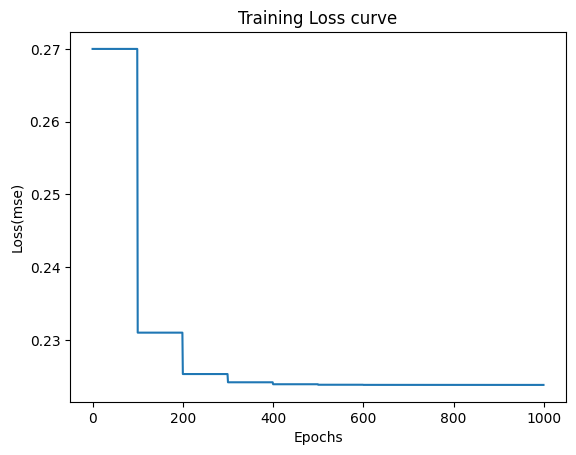

In [168]:
import matplotlib.pyplot as plt 
plt.plot(losses)

plt.title("Training Loss curve")
plt.xlabel("Epochs")
plt.ylabel("Loss(mse)")

In [169]:
#make predictions
y_pred_final = X_bias @ weights 
print("Predictions:", y_pred_final)

Predictions: [[ 0.06253234]
 [ 0.32596676]
 [-0.21390239]
 [-0.16517627]
 [ 0.17429871]
 [-0.13468431]
 [-0.33713702]
 [ 0.17966726]
 [ 0.06154653]
 [-0.1435318 ]
 [-0.15493704]
 [ 0.08859643]
 [ 0.25453702]
 [-0.04399251]
 [ 0.18544593]
 [ 0.20119815]
 [-0.08843746]
 [-0.27394057]
 [-0.02104998]
 [ 0.08589867]
 [ 0.07698582]
 [-0.09296898]
 [ 0.13043564]
 [ 0.18533348]
 [-0.35124121]
 [-0.04545856]
 [-0.06375552]
 [-0.22906378]
 [-0.45297719]
 [ 0.43017481]
 [-0.1107128 ]
 [ 0.0552215 ]
 [-0.17131123]
 [-0.30315738]
 [-0.0238174 ]
 [ 0.1746517 ]
 [-0.17423808]
 [ 0.35419396]
 [ 0.05430344]
 [ 0.03449472]
 [ 0.12907059]
 [ 0.08228061]
 [-0.22464406]
 [-0.01148853]
 [-0.37653339]
 [ 0.05679308]
 [ 0.15251032]
 [ 0.1869406 ]
 [-0.07214513]
 [-0.18777625]
 [-0.03666303]
 [-0.12172617]
 [ 0.21777459]
 [ 0.16030761]
 [ 0.04681461]
 [-0.18993512]
 [-0.18868503]
 [-0.44505903]
 [-0.0933454 ]
 [ 0.25143543]
 [-0.41130301]
 [ 0.45994891]
 [ 0.16818793]
 [ 0.07021469]
 [-0.12693349]
 [-0.2989835

Logistic Regression 


In [170]:
weights = np.zeros((X_bias.shape[1], 1))
learning_rate = 0.01
epochs = 10000

In [171]:
def sigmoid(z):
    return 1/(1+ np.exp(-z))

In [172]:
losses = []
for epoch in range(epochs):
    z = X_bias @ weights 

    y_pred = sigmoid(z)

    gradient = (X_bias.T @ (y_pred - y))/len(y)
    
    weights = weights - (learning_rate * gradient)

    #calculate loss 
    if epoch % 1000 == 0:
        loss = -np.mean(y*np.log(y_pred + 1e-8) + (1-y)*np.log(1-(y_pred+ 1e-8)))
        print("Loss:", loss)
    losses.append(loss)

Loss: 0.6931471897599457
Loss: 0.5969430663405562
Loss: 0.5935983805149891
Loss: 0.5932777492396346
Loss: 0.5932416139865008
Loss: 0.5932373806905866
Loss: 0.593236878724687
Loss: 0.5932368189610859
Loss: 0.5932368118359623
Loss: 0.5932368109861725


Text(0, 0.5, 'Loss')

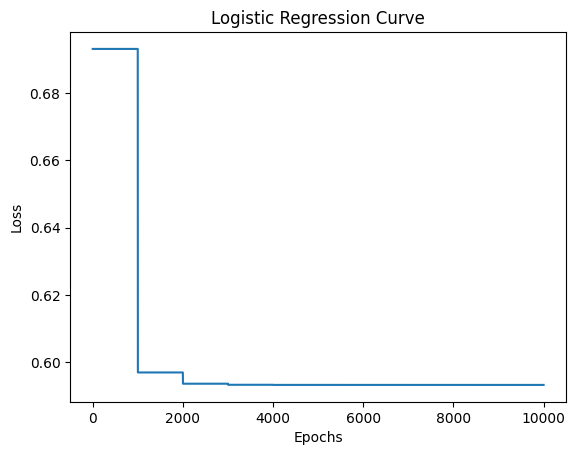

In [173]:
plt.plot(losses)
plt.title("Logistic Regression Curve")

plt.xlabel("Epochs")
plt.ylabel("Loss")

In [174]:
y_pred_proba = sigmoid(X_bias @ weights)  
y_pred_label = (y_pred_proba >=0.5).astype(int)

print("Probability:", y_pred_proba.T)
print("Predict Label:", y_pred_label.T)

Probability: [[0.56932252 0.82736972 0.27310741 0.31273831 0.68843919 0.34851708
  0.16877569 0.69881928 0.57747346 0.34881495 0.33048887 0.60839537
  0.76437229 0.45620366 0.70650356 0.71794278 0.39618271 0.21608279
  0.46815321 0.60228639 0.57431644 0.39309731 0.64991735 0.70460486
  0.16089742 0.45156375 0.42154026 0.25583136 0.1064071  0.88924796
  0.37123704 0.56863928 0.30567426 0.1931547  0.46405497 0.68526365
  0.30005092 0.83624403 0.56619584 0.54539825 0.66063073 0.59640421
  0.2637473  0.47677705 0.14247345 0.55614692 0.67609718 0.70700576
  0.43503614 0.29701566 0.44439149 0.35525231 0.74246289 0.67608847
  0.55416387 0.30132661 0.28955237 0.1059972  0.39383246 0.76884785
  0.1189617  0.90195786 0.67968805 0.57504161 0.34815211 0.18931396
  0.77570655 0.65703888 0.7825822  0.8692267  0.28869478 0.7175205
  0.57488407 0.77747599 0.48275826 0.79237963 0.50120584 0.22623614
  0.79748328 0.24181978 0.35938968 0.29876594 0.83860364 0.50116039
  0.27052129 0.14732717 0.22433222 0